In [1]:
import requests

url = "https://api.jolpi.ca/ergast/f1/2025/1/results.json"
response = requests.get(url)

print(response.status_code)

200


In [2]:
data = response.json()
data

{'MRData': {'xmlns': '',
  'series': 'f1',
  'url': 'https://api.jolpi.ca/ergast/f1/2025/1/results.json',
  'limit': '30',
  'offset': '0',
  'total': '20',
  'RaceTable': {'season': '2025',
   'round': '1',
   'Races': [{'season': '2025',
     'round': '1',
     'url': 'https://en.wikipedia.org/wiki/2025_Australian_Grand_Prix',
     'raceName': 'Australian Grand Prix',
     'Circuit': {'circuitId': 'albert_park',
      'url': 'https://en.wikipedia.org/wiki/Albert_Park_Circuit',
      'circuitName': 'Albert Park Grand Prix Circuit',
      'Location': {'lat': '-37.8497',
       'long': '144.968',
       'locality': 'Melbourne',
       'country': 'Australia'}},
     'date': '2025-03-16',
     'time': '04:00:00Z',
     'Results': [{'number': '4',
       'position': '1',
       'positionText': '1',
       'points': '25',
       'Driver': {'driverId': 'norris',
        'permanentNumber': '1',
        'code': 'NOR',
        'url': 'http://en.wikipedia.org/wiki/Lando_Norris',
        'givenNa

In [3]:
race = data['MRData']['RaceTable']['Races'][0]
results = race['Results']
print(len(results))
results[0]

20


{'number': '4',
 'position': '1',
 'positionText': '1',
 'points': '25',
 'Driver': {'driverId': 'norris',
  'permanentNumber': '1',
  'code': 'NOR',
  'url': 'http://en.wikipedia.org/wiki/Lando_Norris',
  'givenName': 'Lando',
  'familyName': 'Norris',
  'dateOfBirth': '1999-11-13',
  'nationality': 'British'},
 'Constructor': {'constructorId': 'mclaren',
  'url': 'https://en.wikipedia.org/wiki/McLaren',
  'name': 'McLaren',
  'nationality': 'British'},
 'grid': '1',
 'laps': '57',
 'status': 'Finished',
 'Time': {'millis': '6126304', 'time': '1:42:06.304'},
 'FastestLap': {'rank': '1', 'lap': '43', 'Time': {'time': '1:22.167'}}}

In [4]:
extracted = []

for r in results:
    extracted.append({
        'driver_name': r['Driver']['givenName'] + ' ' + r['Driver']['familyName'],
        'constructor': r['Constructor']['name'],
        'grid_position': int(r['grid']),
        'finish_position': int(r['position']),
        'points': float(r['points'])
    })

extracted[:3]

[{'driver_name': 'Lando Norris',
  'constructor': 'McLaren',
  'grid_position': 1,
  'finish_position': 1,
  'points': 25.0},
 {'driver_name': 'Max Verstappen',
  'constructor': 'Red Bull',
  'grid_position': 3,
  'finish_position': 2,
  'points': 18.0},
 {'driver_name': 'George Russell',
  'constructor': 'Mercedes',
  'grid_position': 4,
  'finish_position': 3,
  'points': 15.0}]

In [5]:
import pandas as pd

df = pd.DataFrame(extracted)
df

,driver_name,constructor,grid_position,finish_position,points
0,Lando Norris,McLaren,1,1,25.0
1,Max Verstappen,Red Bull,3,2,18.0
2,George Russell,Mercedes,4,3,15.0
3,Andrea Kimi Antonelli,Mercedes,16,4,12.0
4,Alexander Albon,Williams,6,5,10.0
5,Lance Stroll,Aston Martin,13,6,8.0
6,Nico Hülkenberg,Sauber,17,7,6.0
7,Charles Leclerc,Ferrari,7,8,4.0
8,Oscar Piastri,McLaren,2,9,2.0
9,Lewis Hamilton,Ferrari,8,10,1.0


In [6]:
def get_race_results(season, round_num):
    url = f"https://api.jolpi.ca/ergast/f1/{season}/{round_num}/results.json"
    response = requests.get(url)
    data = response.json()
    
    races = data['MRData']['RaceTable']['Races']
    if not races:
        return None  # no data for this race
    
    race = races[0]
    results = race['Results']
    
    extracted = []
    for r in results:
        extracted.append({
            'season': season,
            'round': round_num,
            'race_name': race['raceName'],
            'driver_name': r['Driver']['givenName'] + ' ' + r['Driver']['familyName'],
            'constructor': r['Constructor']['name'],
            'grid_position': int(r['grid']),
            'finish_position': int(r['position']),
            'points': float(r['points'])
        })
    
    return pd.DataFrame(extracted)

In [7]:
test = get_race_results(2025, 1)
test.head()

,season,round,race_name,driver_name,constructor,grid_position,finish_position,points
0,2025,1,Australian Grand Prix,Lando Norris,McLaren,1,1,25.0
1,2025,1,Australian Grand Prix,Max Verstappen,Red Bull,3,2,18.0
2,2025,1,Australian Grand Prix,George Russell,Mercedes,4,3,15.0
3,2025,1,Australian Grand Prix,Andrea Kimi Antonelli,Mercedes,16,4,12.0
4,2025,1,Australian Grand Prix,Alexander Albon,Williams,6,5,10.0


In [8]:
import time

all_races = []

for round_num in range(1, 25):
    print(f"Fetching round {round_num}...")
    race_df = get_race_results(2025, round_num)
    
    if race_df is None:
        print(f"No data for round {round_num}, stopping.")
        break
    
    all_races.append(race_df)
    time.sleep(0.5)

season_df = pd.concat(all_races, ignore_index=True)
print(f"\nTotal rows: {len(season_df)}")
season_df.head()

Fetching round 1...
Fetching round 2...
Fetching round 3...
Fetching round 4...
Fetching round 5...
Fetching round 6...
Fetching round 7...
Fetching round 8...
Fetching round 9...
Fetching round 10...
Fetching round 11...
Fetching round 12...
Fetching round 13...
Fetching round 14...
Fetching round 15...
Fetching round 16...
Fetching round 17...
Fetching round 18...
Fetching round 19...
Fetching round 20...
Fetching round 21...
Fetching round 22...
Fetching round 23...
Fetching round 24...

Total rows: 479


,season,round,race_name,driver_name,constructor,grid_position,finish_position,points
0,2025,1,Australian Grand Prix,Lando Norris,McLaren,1,1,25.0
1,2025,1,Australian Grand Prix,Max Verstappen,Red Bull,3,2,18.0
2,2025,1,Australian Grand Prix,George Russell,Mercedes,4,3,15.0
3,2025,1,Australian Grand Prix,Andrea Kimi Antonelli,Mercedes,16,4,12.0
4,2025,1,Australian Grand Prix,Alexander Albon,Williams,6,5,10.0


In [9]:
season_df.to_csv('../data/f1_2025_results.csv', index=False)
print("Saved!")

Saved!


In [10]:
print(season_df.shape)
print()
print(season_df.dtypes)
print()
print(season_df.isnull().sum())
print()
season_df.describe()

(479, 8)

season               int64
round                int64
race_name           object
driver_name         object
constructor         object
grid_position        int64
finish_position      int64
points             float64
dtype: object

season             0
round              0
race_name          0
driver_name        0
constructor        0
grid_position      0
finish_position    0
points             0
dtype: int64



,season,round,grid_position,finish_position,points
count,479.0,479.000000,479.000000,479.000000,479.000000
mean,2025.0,12.507307,10.480167,10.480167,5.060543
std,0.0,6.934802,5.761937,5.761937,7.183961
min,2025.0,1.000000,1.000000,1.000000,0.000000
25%,2025.0,6.500000,5.500000,5.500000,0.000000
50%,2025.0,13.000000,10.000000,10.000000,1.000000
75%,2025.0,18.500000,15.000000,15.000000,9.000000
max,2025.0,24.000000,20.000000,20.000000,25.000000


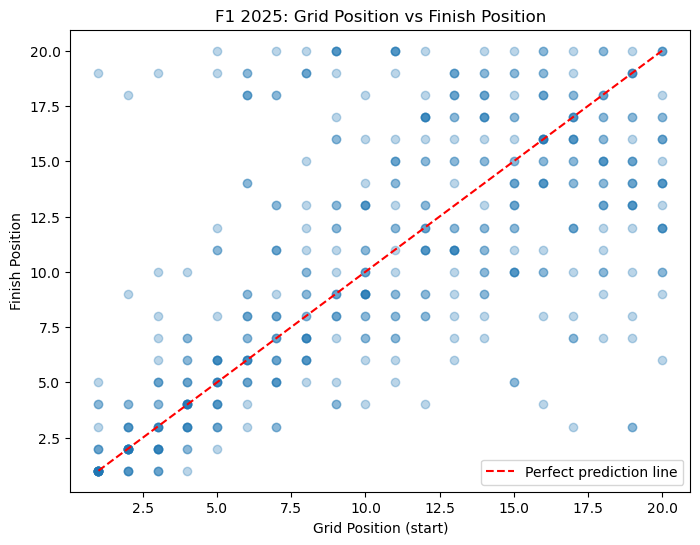

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(season_df['grid_position'], season_df['finish_position'], alpha=0.3)
plt.plot([1, 20], [1, 20], 'r--', label='Perfect prediction line')
plt.xlabel('Grid Position (start)')
plt.ylabel('Finish Position')
plt.title('F1 2025: Grid Position vs Finish Position')
plt.legend()
plt.show()

In [12]:
correlation = season_df['grid_position'].corr(season_df['finish_position'])
print(f"Correlation: {correlation:.3f}")

Correlation: 0.651


In [13]:
!pip install mysql-connector-python sqlalchemy

In [16]:
import pandas as pd
season_df = pd.read_csv('../data/f1_2025_results.csv')
print(season_df.shape)

(479, 8)


In [17]:
import sys
sys.path.append('..')
from config import DB_USER, DB_PASSWORD, DB_HOST, DB_PORT, DB_NAME
from sqlalchemy import create_engine

engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [18]:
drivers_df = season_df[['driver_name']].drop_duplicates().reset_index(drop=True)
print(f"Unique drivers: {len(drivers_df)}")
drivers_df.head()

Unique drivers: 21


,driver_name
0,Lando Norris
1,Max Verstappen
2,George Russell
3,Andrea Kimi Antonelli
4,Alexander Albon


In [19]:
drivers_df.to_sql('drivers', con=engine, if_exists='append', index=False)
print("Drivers loaded")

Drivers loaded


In [20]:
drivers_lookup = pd.read_sql('SELECT driver_id, driver_name FROM drivers', con=engine)
drivers_lookup.head()

,driver_id,driver_name
0,1,Lando Norris
1,2,Max Verstappen
2,3,George Russell
3,4,Andrea Kimi Antonelli
4,5,Alexander Albon


In [21]:
races_df = season_df[['season', 'round', 'race_name']].drop_duplicates().reset_index(drop=True)
races_df = races_df.rename(columns={'race_name': 'circuit_name'})
print(f"Unique races: {len(races_df)}")
races_df.head()

Unique races: 24


,season,round,circuit_name
0,2025,1,Australian Grand Prix
1,2025,2,Chinese Grand Prix
2,2025,3,Japanese Grand Prix
3,2025,4,Bahrain Grand Prix
4,2025,5,Saudi Arabian Grand Prix


In [22]:
races_df.to_sql('races', con=engine, if_exists='append', index=False)

races_lookup = pd.read_sql('SELECT race_id, season, round, circuit_name FROM races', con=engine)
print(f"Races in database: {len(races_lookup)}")
races_lookup.head()

Races in database: 24


,race_id,season,round,circuit_name
0,1,2025,1,Australian Grand Prix
1,2,2025,2,Chinese Grand Prix
2,3,2025,3,Japanese Grand Prix
3,4,2025,4,Bahrain Grand Prix
4,5,2025,5,Saudi Arabian Grand Prix


In [24]:
results_df = season_df.merge(drivers_lookup, on='driver_name', how='left')

results_df = results_df.merge(
    races_lookup[['race_id', 'season', 'round']],
    on=['season', 'round'],
    how='left'
)

print(results_df.shape)
results_df.head()

(479, 10)


,season,round,race_name,driver_name,constructor,grid_position,finish_position,points,driver_id,race_id
0,2025,1,Australian Grand Prix,Lando Norris,McLaren,1,1,25.0,1,1
1,2025,1,Australian Grand Prix,Max Verstappen,Red Bull,3,2,18.0,2,1
2,2025,1,Australian Grand Prix,George Russell,Mercedes,4,3,15.0,3,1
3,2025,1,Australian Grand Prix,Andrea Kimi Antonelli,Mercedes,16,4,12.0,4,1
4,2025,1,Australian Grand Prix,Alexander Albon,Williams,6,5,10.0,5,1


In [25]:
print(results_df['driver_id'].isnull().sum())
print(results_df['race_id'].isnull().sum())

0
0


In [26]:
results_df[['season', 'round', 'race_name', 'driver_name', 'race_id', 'driver_id']].iloc[18:25]

,season,round,race_name,driver_name,race_id,driver_id
18,2025,1,Australian Grand Prix,Jack Doohan,1,19
19,2025,1,Australian Grand Prix,Isack Hadjar,1,20
20,2025,2,Chinese Grand Prix,Oscar Piastri,2,9
21,2025,2,Chinese Grand Prix,Lando Norris,2,1
22,2025,2,Chinese Grand Prix,George Russell,2,3
23,2025,2,Chinese Grand Prix,Max Verstappen,2,2
24,2025,2,Chinese Grand Prix,Esteban Ocon,2,13


In [27]:
results_to_load = results_df[['race_id', 'driver_id', 'grid_position', 'finish_position', 'points']]

results_to_load.to_sql('results', con=engine, if_exists='append', index=False)
print(f"Loaded {len(results_to_load)} results")

Loaded 479 results


In [28]:
check = pd.read_sql("""
    SELECT COUNT(*) AS total_results
    FROM results
""", con=engine)
print(check)

   total_results
0            479


In [29]:
query = """
SELECT 
    d.driver_name,
    COUNT(*) AS races_entered,
    AVG(r.grid_position) AS avg_grid,
    AVG(r.finish_position) AS avg_finish,
    SUM(r.points) AS total_points
FROM results r
JOIN drivers d ON r.driver_id = d.driver_id
GROUP BY d.driver_name
ORDER BY total_points DESC
"""

driver_summary = pd.read_sql(query, con=engine)
driver_summary.head(10)

,driver_name,races_entered,avg_grid,avg_finish,total_points
0,Lando Norris,24,2.9583,4.2500,394.0
1,Max Verstappen,24,3.5833,3.6667,389.0
2,Oscar Piastri,24,3.0000,4.2083,381.0
3,George Russell,24,4.3750,4.5417,289.0
4,Charles Leclerc,24,5.4167,6.7500,225.0
5,Andrea Kimi Antonelli,24,8.7500,9.8333,135.0
6,Lewis Hamilton,24,9.3750,8.5000,135.0
7,Alexander Albon,24,12.7500,11.0417,70.0
8,Carlos Sainz,24,11.1667,12.1667,54.0
9,Nico Hülkenberg,24,14.7083,12.7917,51.0


In [30]:
query_text = """-- Driver season summary: qualifying vs race performance
SELECT 
    d.driver_name,
    COUNT(*) AS races_entered,
    AVG(r.grid_position) AS avg_grid,
    AVG(r.finish_position) AS avg_finish,
    SUM(r.points) AS total_points
FROM results r
JOIN drivers d ON r.driver_id = d.driver_id
GROUP BY d.driver_name
ORDER BY total_points DESC;
"""

with open('../sql/driver_summary.sql', 'w') as f:
    f.write(query_text)

print("Saved to sql/driver_summary.sql")

Saved to sql/driver_summary.sql


In [31]:
readme = """# F1 Race Outcome Predictor

Predicting Formula 1 finishing positions from qualifying grid position using Python, MySQL, and machine learning.

## Project overview

This project explores how much a driver's starting grid position determines their race result, using 2025 Formula 1 season data.

**Key finding so far:** grid position correlates 0.651 with finishing position, explaining roughly 42% of the variance. Grid position matters substantially, but leaves most of the outcome unexplained.

## Tech stack

- **Python** (pandas, matplotlib, scikit-learn) - extraction, analysis, modelling
- **MySQL** - normalized relational storage
- **Jupyter** - exploratory analysis
- **Tableau** - dashboards
- **n8n** - automated data pipeline

## Data source

[jolpica-f1 API](https://api.jolpi.ca/) - the community-maintained successor to the deprecated Ergast API. Free, no authentication required.

## Database schema

Three normalized tables:
- `drivers` - one row per driver
- `races` - one row per Grand Prix
- `results` - one row per driver per race, linked to both via foreign keys

## Known limitations

- The `races.circuit_name` column currently stores the race name (e.g. "Australian Grand Prix") rather than the actual circuit name (e.g. "Albert Park"). These are conceptually different and should be separate columns.
- `races.race_date` is not currently populated, though the API provides it.
- Only 2025 season data loaded so far; more seasons needed for robust modelling.

## Setup

Requires a local MySQL instance and a `config.py` file in the project root (gitignored) containing database credentials.

## Progress

- [x] Data extraction from API
- [x] MySQL schema design and loading
- [x] Exploratory data analysis
- [ ] Prediction model
- [ ] Tableau dashboard
- [ ] n8n automated pipeline
"""

with open('../README.md', 'w') as f:
    f.write(readme)

print("README updated")

README updated
